# Scenario 5 – SMOTE

**Name:** SaiSanjay R

**Roll No:** 24BAD102

    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0
Fraud
0    110
1     10
Name: count, dtype: int64


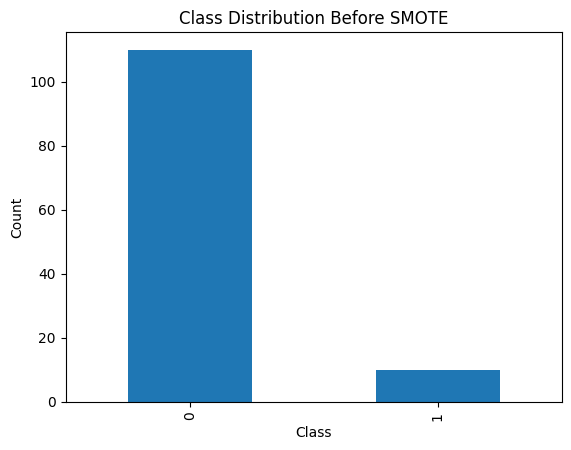

Accuracy Before SMOTE: 0.9166666666666666


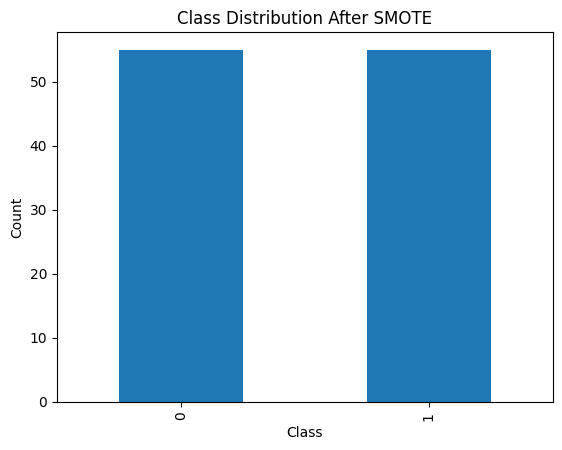

Accuracy After SMOTE: 0.5833333333333334


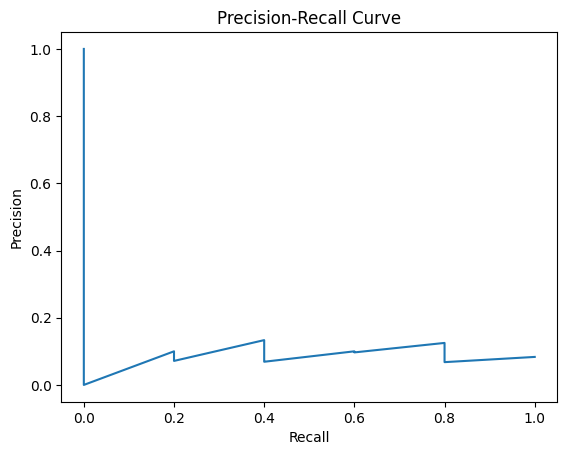

In [6]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_curve

from imblearn.over_sampling import SMOTE

# 2. Load Dataset
df = pd.read_csv("fraud_smote.csv")

print(df.head())

# 3. Check Class Imbalance
print(df['Fraud'].value_counts())

# Visualization - Class Distribution (Before SMOTE)
df['Fraud'].value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 4. Define Features and Target
X = df.drop('Fraud', axis=1)
y = df['Fraud']

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# 6. Train Model Before SMOTE
model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

pred_before = model_before.predict(X_test)
acc_before = accuracy_score(y_test, pred_before)

print("Accuracy Before SMOTE:", acc_before)

# 7. Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=4) # Changed k_neighbors from default 5 to 4

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Visualization - Class Distribution After SMOTE
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 8. Train Model After SMOTE
model_after = LogisticRegression(max_iter=1000)
model_after.fit(X_train_sm, y_train_sm)

pred_after = model_after.predict(X_test)
acc_after = accuracy_score(y_test, pred_after)

print("Accuracy After SMOTE:", acc_after)

# 9. Precision-Recall Curve
prob = model_after.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()